# Balancing the Dataset and Evaluation Metrics

The GTSRB is a notoriously unbalanced dataset. In this notebook, we will explore the pros and cons of class balancing and its impact on model performance.

Balancing a dataset is typically achieved by either undersampling the majority classes or generating more data for the underrepresented classes (oversampling).

The first approach reduces computational load but risks discarding highly valuable, discriminative information needed to map the true underlying data distribution. Conversely, generating more data for the minority classes increases training time and introduces the risk of overfitting, particularly if the model simply memorizes duplicated patterns or noise.

Here, we focus on the second approach. Specifically, we test whether the model improves its generalization ability when the minority classes are oversampled using data augmentation  with simple geometric and color operations. This augmented dataset, generated in notebook "06.0_balance.ipynb", aims to artificially expand the minority classes while adding enough variance to prevent exact pattern memorization.

To evaluate these models we will introduce some metrics, namely recall, precision, and F1-score. These will allow a more granular evaluation when compared to using accuracy alone.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import sys
sys.path.insert(1, 'util')
import vcpi_util


<module 'vcpi_util' from 'd:\\vcpi-github\\Deep-Learning-Course-PyTorch\\util\\vcpi_util.py'>

# Auxiliary functions from previous classes

In [ ]:
def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}
    history['accuracy'] = []
    history['val_acc'] = []
    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets) in enumerate(train_loader, 0):
            
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (predicted == targets).sum()

        model.eval()
        with torch.no_grad():
            v_correct = 0
            val_loss = 0.0
            for i,t in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)
                
                val_loss += loss_fn(o, t).item() * t.size(0)

                v_correct += (p == t).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; Val Loss: {val_loss:0.6f}; Val Acc: {v_accuracy:0.4f}; Elapsed time: {(stop_time - start_time):0.4f}')
        history['accuracy'].append(accuracy.cpu().numpy())
        history['val_acc'].append(v_accuracy.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['loss'].append(epoch)
 
        ###### Saving ######
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)



def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    
    for i, (images, targets) in enumerate(data_loader):
         
        # forward pass, compute the output of the model for the current batch
        outputs = model(images.to(device))

        # "max" returns a namedtuple (values, indices) where values is the maximum 
        # value of each row of the input tensor in the given dimension dim; 
        # indices is the index location of each maximum value found (argmax).
        # the argmax effectively provides the predicted class number        
        _, preds = torch.max(outputs, dim=1)

        correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()


class Conv_II(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        
        # Block 1
        self.conv1 = torch.nn.Conv2d(3, 16, 3)
        self.bn1 = torch.nn.BatchNorm2d(16)
        self.relu1 = torch.nn.ReLU()
        
        self.conv2 = torch.nn.Conv2d(16, 32, 3)
        self.bn2 = torch.nn.BatchNorm2d(32)
        self.relu2 = torch.nn.ReLU()
        
        self.maxpool1 = torch.nn.MaxPool2d(2)

        # Block 2
        self.conv3 = torch.nn.Conv2d(32, 48, 3)
        self.bn3 = torch.nn.BatchNorm2d(48)
        self.relu3 = torch.nn.ReLU()
        
        self.conv4 = torch.nn.Conv2d(48, 48, 3)
        self.bn4 = torch.nn.BatchNorm2d(48)
        self.relu4 = torch.nn.ReLU()
        
        self.maxpool2 = torch.nn.MaxPool2d(2)
    
        # Dropout (p=0.5 drops 50% of the neurons randomly during training)
        self.dropout = torch.nn.Dropout(p=0.5)

        # Fully Connected (GAP outputs 48 channels as scalars -> 48 inputs)
        self.fc1 = torch.nn.Linear(48, num_classes)
        

    def forward(self, x):    
        
        # input = (bs, 3, 32, 32)
        x = self.conv1(x)       # -> (bs, 16, 30, 30)
        x = self.bn1(x)
        x = self.relu1(x)
        
        x = self.conv2(x)       # -> (bs, 32, 28, 28)
        x = self.bn2(x)
        x = self.relu2(x)
        
        x = self.maxpool1(x)    # -> (bs, 32, 14, 14)
        
        x = self.conv3(x)       # -> (bs, 48, 12, 12)
        x = self.bn3(x)
        x = self.relu3(x)
        
        x = self.conv4(x)       # -> (bs, 48, 10, 10)
        x = self.bn4(x)
        x = self.relu4(x)
        
        x = self.maxpool2(x)    # -> (bs, 48, 5, 5)
        
        # Apply GAP using torch.mean
        x = torch.mean(x, dim=[2, 3])   # -> (bs, 48)
        
        # Flatten for the Linear Layer
        x = torch.flatten(x, 1) # -> (bs, 48)
        
        # Apply Dropout
        x = self.dropout(x)
        
        # Classifier
        x = self.fc1(x)         # -> (bs, 10)

        return x



class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta
        self.counter = 0

        self.min_delta
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    


def build_confusion_matrix(model, dataset):

    preds = []
    ground_truth = []

    for images, targets in dataset:

        predictions = model(images.to(device))
        preds_sparse = [np.argmax(x) for x in predictions.cpu().detach().numpy()]
        preds.extend(preds_sparse)
        ground_truth.extend(targets.numpy())

    vcpi_util.show_confusion_matrix(ground_truth, preds, len(test_set.classes))      


def build_unnormalized_confusion_matrix(model, dataset):

    preds = []
    ground_truth = []

    for images, targets in dataset:

        predictions = model(images.to(device))
        preds_sparse = [np.argmax(x) for x in predictions.cpu().detach().numpy()]
        preds.extend(preds_sparse)
        ground_truth.extend(targets.numpy())

    vcpi_util.show_unnormalized_confusion_matrix(ground_truth, preds, len(test_set.classes))      

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

PATH_TRAINING_SET = 'd:/vcpi/gtsrb/train'
PATH_TEST_SET = 'd:/vcpi/gtsrb/test_A'
PATH_VAL_SET = 'd:/vcpi/gtsrb/val'

BATCH_SIZE = 32

EPOCHS = 50

MODE = 'train'

cuda:0


In [4]:
transform = transforms.Compose(
    [transforms.Resize((32,32)), transforms.ToTensor()]) 

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

# No shuffle is required for the test set, also the batch size can be completely different
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE)

val_set = torchvision.datasets.ImageFolder(root=PATH_VAL_SET, transform = transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)


As can be seen in the following histogram, some classes are severely underrepresented.

Counter({2: 1770, 1: 1740, 4: 1590, 5: 1500, 6: 1170, 3: 1140, 7: 1110, 0: 180})


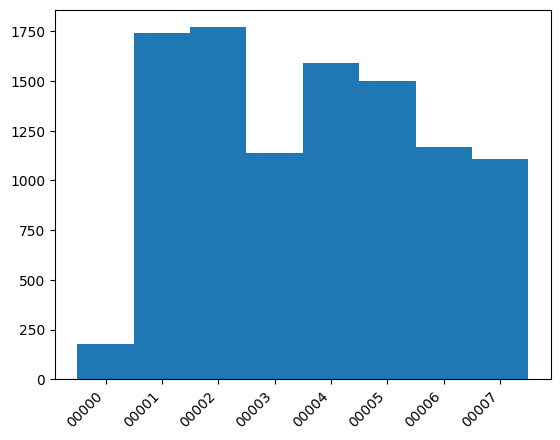

In [5]:
target_list = []
for images, targets in train_loader:
    target_list.extend(targets)

vcpi_util.show_histogram(target_list, train_set.classes)

# Train and evaluate

## Train

In [38]:
RUNS = 5

if MODE == 'train':
    loss_fn = torch.nn.CrossEntropyLoss()

    for i in range(RUNS):
        model_Conv = Conv_II(len(train_set.classes))
        model_Conv.to(device)

        early_stop = Early_Stopping(9)
        optimizer = torch.optim.Adam(model_Conv.parameters())
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    
        history_I = train_III(model_Conv, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'gtsrb_{i}')

Epoch: 000; Loss: 1.699273; Accuracy: 33.6373; Val Loss: 1.799674; Val Acc: 37.0930; Elapsed time: 33.4195
Epoch: 001; Loss: 0.995648; Accuracy: 66.7941; Val Loss: 0.881864; Val Acc: 69.6124; Elapsed time: 6.8665
Epoch: 002; Loss: 0.572314; Accuracy: 82.5588; Val Loss: 0.933350; Val Acc: 63.0620; Elapsed time: 6.8128
Epoch: 003; Loss: 0.359469; Accuracy: 89.5000; Val Loss: 0.590054; Val Acc: 77.8295; Elapsed time: 6.6613
Epoch: 004; Loss: 0.266245; Accuracy: 92.2059; Val Loss: 0.555522; Val Acc: 80.0388; Elapsed time: 6.6425
Epoch: 005; Loss: 0.196921; Accuracy: 94.3235; Val Loss: 0.522461; Val Acc: 82.8682; Elapsed time: 6.6466
Epoch: 006; Loss: 0.150684; Accuracy: 95.8235; Val Loss: 0.180718; Val Acc: 94.6899; Elapsed time: 6.6361
Epoch: 007; Loss: 0.122290; Accuracy: 96.5784; Val Loss: 0.784219; Val Acc: 77.7907; Elapsed time: 6.7436
Epoch: 008; Loss: 0.114340; Accuracy: 96.8529; Val Loss: 0.192311; Val Acc: 93.4884; Elapsed time: 6.8572
Epoch: 009; Loss: 0.078483; Accuracy: 97.9412

## Evaluate

In [39]:
res = 0

for i in range(RUNS):

    reload = torch.load(f'gtsrb_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    print(reload['epoch'], eval)
    res += eval

res /= RUNS    
print(res)

20 0.978657066822052
21 0.9752997756004333
42 0.9808153510093689
16 0.9752997756004333
17 0.973621129989624
0.9767386198043824


# Balanced dataset

Here we use the balanced dataset created in notebook "06.0_balance.ipynb". Each class now has 2000 images, where the new images were created with geometric and color operations.

In [40]:
PATH_BALANCED_TRAINING_SET = 'd:/vcpi/gtsrb/train_balanced_2000'

balanced_train_set = torchvision.datasets.ImageFolder(root=PATH_BALANCED_TRAINING_SET, transform = transform)
balanced_train_loader = torch.utils.data.DataLoader(balanced_train_set, batch_size = BATCH_SIZE, shuffle=True)

Counter({3: 2000, 6: 2000, 7: 2000, 2: 2000, 5: 2000, 4: 2000, 0: 2000, 1: 2000})


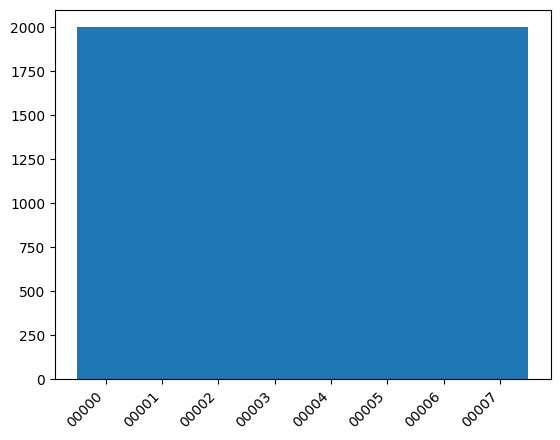

In [41]:
target_list = []
for images, targets in balanced_train_loader:
    target_list.extend(targets)

vcpi_util.show_histogram(target_list, train_set.classes)

## Train runs

In [42]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv = Conv_II(len(train_set.classes))
    model_Conv.to(device)

    early_stop = Early_Stopping(9)
    optimizer = torch.optim.Adam(model_Conv.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv, balanced_train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'gtsrb_balanced_{i}')


Epoch: 000; Loss: 1.547642; Accuracy: 41.0250; Val Loss: 1.760476; Val Acc: 30.4651; Elapsed time: 9.1041
Epoch: 001; Loss: 0.857936; Accuracy: 71.5000; Val Loss: 0.872758; Val Acc: 69.0698; Elapsed time: 9.0709
Epoch: 002; Loss: 0.448341; Accuracy: 86.2438; Val Loss: 0.466850; Val Acc: 83.4884; Elapsed time: 9.1082
Epoch: 003; Loss: 0.278432; Accuracy: 91.8625; Val Loss: 0.736066; Val Acc: 78.8372; Elapsed time: 9.1537
Epoch: 004; Loss: 0.185296; Accuracy: 94.8500; Val Loss: 0.393317; Val Acc: 86.8217; Elapsed time: 9.0923
Epoch: 005; Loss: 0.139844; Accuracy: 96.1750; Val Loss: 0.169247; Val Acc: 94.0310; Elapsed time: 9.0959
Epoch: 006; Loss: 0.104462; Accuracy: 97.1938; Val Loss: 0.152255; Val Acc: 94.7287; Elapsed time: 9.2420
Epoch: 007; Loss: 0.077927; Accuracy: 98.0063; Val Loss: 0.425374; Val Acc: 86.5891; Elapsed time: 9.1124
Epoch: 008; Loss: 0.070158; Accuracy: 98.1750; Val Loss: 0.145907; Val Acc: 94.7674; Elapsed time: 9.6473
Epoch: 009; Loss: 0.055756; Accuracy: 98.6063;

## Evaluate

In [43]:
res = 0

for i in range(RUNS):

    reload = torch.load(f'gtsrb_balanced_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    print(reload['epoch'], eval)
    res += eval

res /= RUNS    
print(res)

26 0.979376494884491
22 0.9827337861061096
29 0.9880095720291138
24 0.9839328527450562
27 0.991127073764801
0.9850359559059143


# Show stats 

## History

The history for the last run for each train set


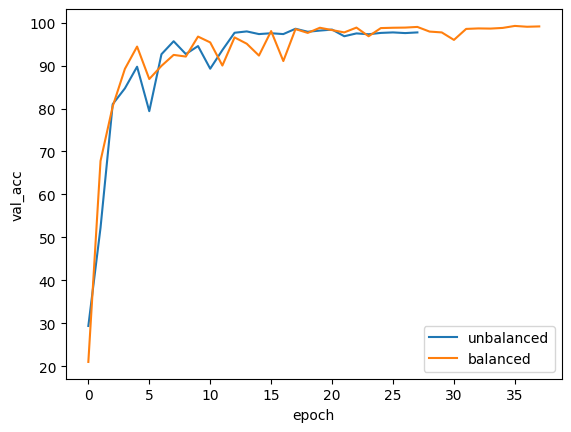

In [44]:
vcpi_util.show_histories([history_I, history_II], ['unbalanced', 'balanced'], 'val_acc')

In [45]:
reload = torch.load(f'gtsrb_{RUNS-1}.pt')
print(reload['epoch'])
model_Conv_I = Conv_II(len(train_set.classes))
model_Conv_I.to(device)
model_Conv_I.load_state_dict(reload['model'])
evaluate(model_Conv_I, test_loader)

17


0.973621129989624

In [46]:
reload = torch.load(f'gtsrb_balanced_{RUNS-1}.pt')
print(reload['epoch'])
model_Conv_II = Conv_II(len(train_set.classes))
model_Conv_II.to(device)
model_Conv_II.load_state_dict(reload['model'])
evaluate(model_Conv_II, test_loader)

27


0.991127073764801

# Metrics

The accuracies obtained in both models show that the model trained with balanced data performs better on the test set. However, accuracy alone can be a misleading metric when dealing with imbalanced distributions, as is the case of the test set.

To properly assess the impact of balancing, we need to dive deeper into metrics to evaluate the pros and cons of balancing at a more granular level.

The metrics detailed here are recall, precision, and F1-score. Furthermore, we will explore how to compute them for the multiclass setting, where each sample has a single label, which is the most common scenario in image classification.

## Confusion Matrices

Confusion matrices have been presented in previous notebooks as percentages. However, to compute these metrics we need to display the raw classification counts.



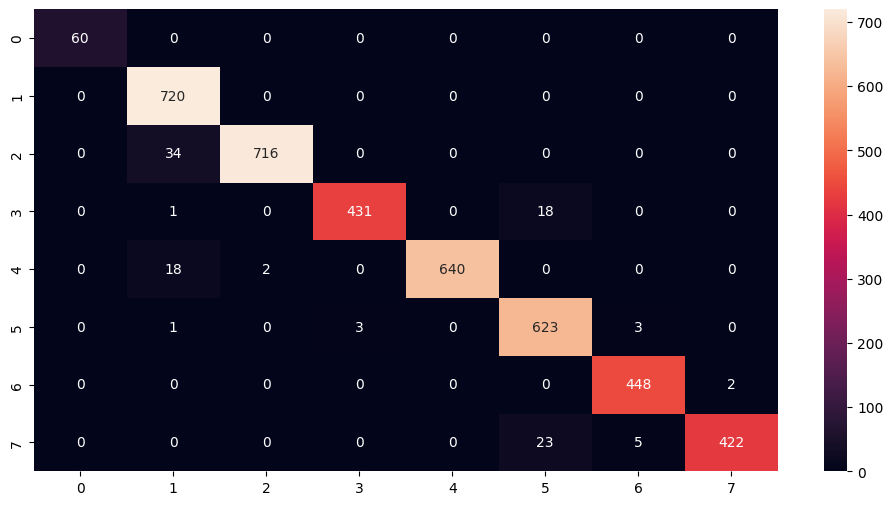

In [47]:
build_unnormalized_confusion_matrix(model_Conv_I, test_loader)

Each column represents the model *predicted* classification, whereas each row represents the actual *ground truth*. 

For instance, summing the elements for the row labeled 3 we get $1 + 436 + 13 = 450$. This is the total number of actual images belonging to class 3. Conversely, summing all the elements in the column for class 3 gives us the total count for the images that the model *predicted* as class 3. In this case, the model predicted $436 + 1 = 437$ images as belonging to class 3. 

Based on the confusion matrix, we can define four classification outcomes considering any particular class:

- True Positive (TP): an image correctly classified as belonging to that class (this is the diagonal of the matrix)

- False Positive (FP): an image incorrectly classified as belonging to that class (all the elements in the column, excluding the diagonal)

- True Negative (TN): an image from any other class correctly identified as not belonging to this class (all other columns, excluding the row relative to the class).

- False Negative (FN): an image from that class, incorrectly classified as belonging to any other class (the row of the class, excluding the element in the diagonal)

Considering class 3, we have:

- TP = 436 

- FP = 1

- TN =  $\text{total images} - \text{actual class 3} - \text{FP for class 3} $= 4170 - 450 - 1 = 3719$

- FN = $1 + 13 = 14$

Based on these classification outcomes we can now compute the metrics mentioned above for class 3:

### Recall

The proportion of images belonging to class 3 that are correctly classified as class 3

$R = {\Large \frac{TP}{TP + FN} = \frac{436}{436 + 14} } = 96.89\% $

### Precision

The proportion of images predicted as class 3 tht actually belong to class 3

$P = {\Large \frac{TP}{TP + FP} = \frac{436}{436 + 1} } = 99.77\% $

### F1-score

The harmonic mean of recall and precision

$F = {\Large \frac{2 \times R \times P}{R + P} = \frac{2 \times 0.9689 \times 0.9977}{0.9689 + 0.9977} } = 98.31\%$


Above it was shown how o compute the metrics for a particular class. To compute these metrics for the whole dataset several averaging options are available:

- Micro Averaging: Considers all TP, FP, and FN globally across all classes to compute the metric. In a multiclass setting where all images have exactly one label, micro-recall, micro-precision and micro-F1 are all mathematically equal to the overall global accuracy.

- Macro Averaging: Considers the mean of the metrics computed separately for each class, treating every class as equally important. A bad recall in a small class has the same influence as a bad recall in a larger class.

- Weighted Averaging: Similar to Macro-Averaging, but the metrics for each class are weighted by the percentage of elements of that class in the dataset. Compared to macro averaging, this method downplays smaller classes and up-weights larger classes, so the final score is a reflection of the model's performance on the whole dataset. The downside is that is masks poor performance on very small classes.


Evaluating Model I...
Evaluating Model II...

Classification Report: Unbalanced
-------------------------------------------------------
              precision    recall  f1-score   support

       00000     1.0000    1.0000    1.0000        60
       00001     0.9302    1.0000    0.9639       720
       00002     0.9972    0.9547    0.9755       750
       00003     0.9931    0.9578    0.9751       450
       00004     1.0000    0.9697    0.9846       660
       00005     0.9383    0.9889    0.9629       630
       00006     0.9825    0.9956    0.9890       450
       00007     0.9953    0.9378    0.9657       450

    accuracy                         0.9736      4170
   macro avg     0.9796    0.9755    0.9771      4170
weighted avg     0.9750    0.9736    0.9737      4170


Classification Report: Balanced
-------------------------------------------------------
              precision    recall  f1-score   support

       00000     1.0000    1.0000    1.0000        60
       00001   

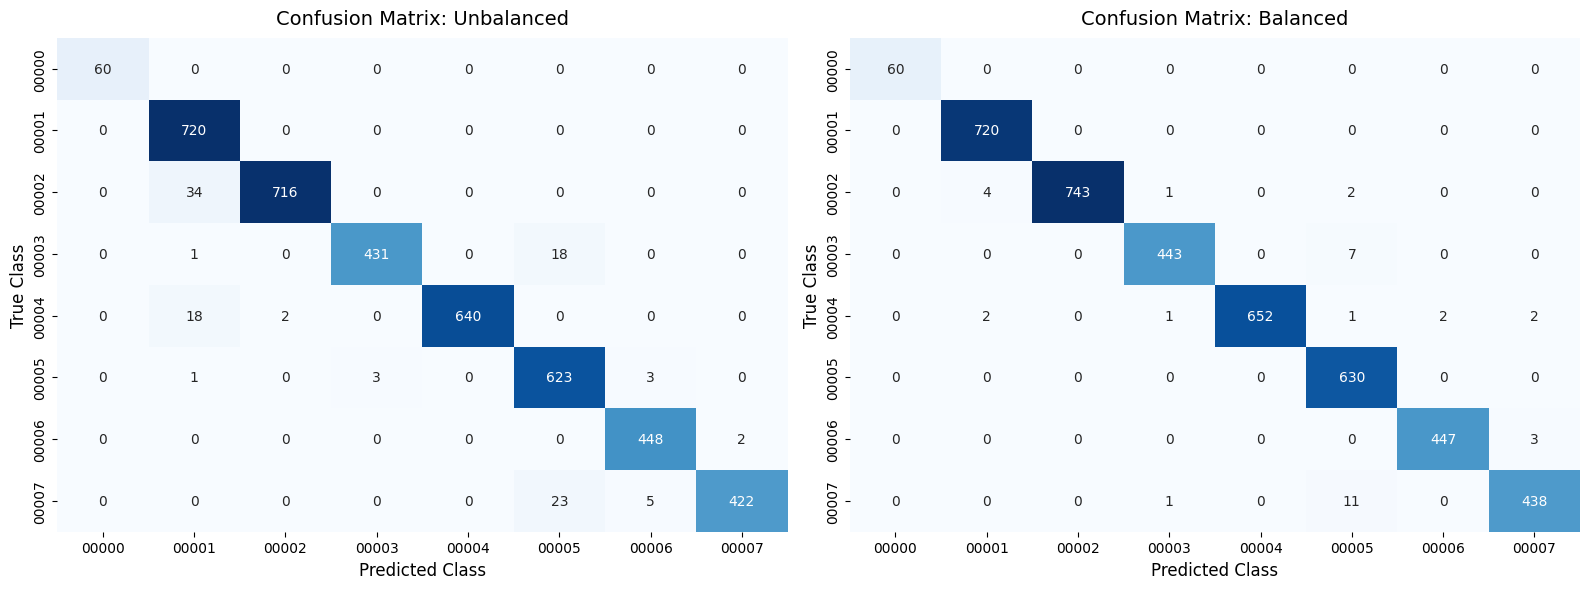

In [48]:
def evaluate_single_model(model, name, dataloader):
    model.eval()
    all_preds, all_targets = [], []
    
    # Count trainable parameters
    
    # Timing and inference

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    total_images = len(all_targets)
    
    return {
        "name": name,
        "targets": all_targets,
        "preds": all_preds,
    }


def compare_models(model1, model2, dataloader, device, class_names=None):
    """
    Evaluates two PyTorch models computing inference FPS, parameter count,
    per-class precision/recall/F1, and visualizes confusion matrices.
    """
        
    print("Evaluating Model I...")
    res1 = evaluate_single_model(model1, "Unbalanced", test_loader)
    
    print("Evaluating Model II...")
    res2 = evaluate_single_model(model2, "Balanced", test_loader)
    
    # 1. Classification Reports (Macro/Micro metrics)
    print(f"\nClassification Report: {res1['name']}")
    print("-" * 55)
    print(classification_report(res1['targets'], res1['preds'], target_names=class_names, digits=4))
    
    print(f"\nClassification Report: {res2['name']}")
    print("-" * 55)
    print(classification_report(res2['targets'], res2['preds'], target_names=class_names, digits=4))
    
    # 2. Confusion Matrices Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for ax, res in zip(axes, [res1, res2]):
        cm = confusion_matrix(res['targets'], res['preds'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                    xticklabels=class_names, yticklabels=class_names, cbar=False)
        ax.set_title(f"Confusion Matrix: {res['name']}", fontsize=14, pad=10)
        ax.set_xlabel('Predicted Class', fontsize=12)
        ax.set_ylabel('True Class', fontsize=12)
        
    plt.tight_layout()
    plt.show()


class_names = [str(c) for c in test_set.classes] if hasattr(test_set, 'classes') else None
compare_models(model_Conv_I, model_Conv_II, test_loader, device, class_names=class_names)

From the results above, the model trained with balanced data, outperforms the model trained with the original training set in all averages. This improvement likely comes from a combination of having more training samples and a more balanced class distribution; the current experiment does not disentangle these two effects.

Performance during inference is the same, as both models share the same architecture. During training, the model trained with balanced data took approximately 1.5 times the number of seconds per epoch.